In [ ]:
!pip install -q transformers==4.46.3 sentencepiece accelerate \
datasets rouge-score bert-score sacrebleu sentence-transformers bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 57.7 MB/s eta 0:00:00


In [ ]:
import os
import gc
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sacrebleu

from tqdm import tqdm
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    AutoModelForCausalLM,
    MBart50TokenizerFast,
    MBartForConditionalGeneration,
    BitsAndBytesConfig
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/ZEROSHOT_BENCHMARK"

os.makedirs(BASE_DIR, exist_ok=True)

for model in ["mt5", "mbart", "bloomz", "sarvam"]:
    os.makedirs(f"{BASE_DIR}/{model}", exist_ok=True)

print(BASE_DIR)

/content/drive/MyDrive/ZEROSHOT_BENCHMARK


In [ ]:
RUN_SPLIT = "validation"

In [ ]:
DATA_PATH = f"/content/drive/MyDrive/ZEROSHOT_BENCHMARK/{RUN_SPLIT}.csv"

df = pd.read_csv(DATA_PATH)

df.dropna(subset=["article", "summary"], inplace=True)

df["article"] = df["article"].astype(str)
df["summary"] = df["summary"].astype(str)

print(df.shape)

(970, 3)


In [ ]:
semantic_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    device="cuda"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()

In [ ]:
def compute_metrics(predictions, references):

    rouge = rouge_scorer.RougeScorer(
        ['rouge1', 'rouge2', 'rougeL'],
        use_stemmer=False
    )

    r1, r2, rl = [], [], []

    for ref, pred in zip(references, predictions):
        scores = rouge.score(ref, pred)

        r1.append(scores["rouge1"].fmeasure)
        r2.append(scores["rouge2"].fmeasure)
        rl.append(scores["rougeL"].fmeasure)

    bleu = sacrebleu.corpus_bleu(predictions, [references])

    pred_emb = semantic_model.encode(
        predictions,
        batch_size=32,
        convert_to_tensor=True
    )

    ref_emb = semantic_model.encode(
        references,
        batch_size=32,
        convert_to_tensor=True
    )

    semantic_scores = util.cos_sim(
        pred_emb,
        ref_emb
    ).diag().cpu().numpy()

    metrics_df = pd.DataFrame({
        "Metric": [
            "ROUGE-1",
            "ROUGE-2",
            "ROUGE-L",
            "BLEU",
            "BERTScore"
        ],
        "Score": [
            np.mean(r1),
            np.mean(r2),
            np.mean(rl),
            bleu.score,
            np.mean(semantic_scores)
        ]
    })

    rouge_df = pd.DataFrame({
        "ROUGE-1": r1,
        "ROUGE-2": r2,
        "ROUGE-L": rl
    })

    return metrics_df, rouge_df

In [ ]:
def save_outputs(model_name, predictions, references, articles):

    model_dir = f"{SAVE_DIR}/{model_name}"
    os.makedirs(model_dir, exist_ok=True)

    pred_df = pd.DataFrame({
        "Article": articles,
        "Reference": references,
        "Prediction": predictions
    })

    pred_df.to_csv(
        f"{model_dir}/predictions.csv",
        index=False
    )

    pred_df.sample(
        min(10, len(pred_df)),
        random_state=42
    ).to_csv(
        f"{model_dir}/sample_predictions.csv",
        index=False
    )

    metrics_df, rouge_df = compute_metrics(
        predictions,
        references
    )

    metrics_df.to_csv(
        f"{model_dir}/metrics.csv",
        index=False
    )

    rouge_df.to_csv(
        f"{model_dir}/rouge_scores.csv",
        index=False
    )

    plt.figure(figsize=(8,6))
    plt.bar(metrics_df["Metric"], metrics_df["Score"])
    plt.xticks(rotation=45)
    plt.title(f"{model_name.upper()} Metrics")
    plt.tight_layout()
    plt.savefig(f"{model_dir}/metrics_plot.png")
    plt.show()

    plt.figure(figsize=(8,6))
    plt.hist(rouge_df["ROUGE-1"], bins=30, alpha=0.6, label="ROUGE-1")
    plt.hist(rouge_df["ROUGE-2"], bins=30, alpha=0.6, label="ROUGE-2")
    plt.hist(rouge_df["ROUGE-L"], bins=30, alpha=0.6, label="ROUGE-L")
    plt.legend()
    plt.title(f"{model_name.upper()} ROUGE Distribution")
    plt.tight_layout()
    plt.savefig(f"{model_dir}/rouge_distribution.png")
    plt.show()

    with open(
        f"{model_dir}/report.txt",
        "w",
        encoding="utf-8"
    ) as f:
        for _, row in metrics_df.iterrows():
            f.write(f"{row['Metric']}: {row['Score']:.4f}\n")

    print(f"\n===== {model_name.upper()} METRICS =====")
    display(metrics_df)

    print("\n===== SAMPLE PREDICTIONS =====")
    display(pred_df.sample(min(5, len(pred_df)), random_state=42))

    print(f"\nSaved to: {model_dir}")

In [ ]:
clear_memory()

MODEL = "google/mt5-small"

tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL).to("cuda")
model.eval()

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

MT5ForConditionalGeneration(
  (shared): Embedding(250112, 512)
  (encoder): MT5Stack(
    (embed_tokens): Embedding(250112, 512)
    (block): ModuleList(
      (0): MT5Block(
        (layer): ModuleList(
          (0): MT5LayerSelfAttention(
            (SelfAttention): MT5Attention(
              (q): Linear(in_features=512, out_features=384, bias=False)
              (k): Linear(in_features=512, out_features=384, bias=False)
              (v): Linear(in_features=512, out_features=384, bias=False)
              (o): Linear(in_features=384, out_features=512, bias=False)
              (relative_attention_bias): Embedding(32, 6)
            )
            (layer_norm): MT5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): MT5LayerFF(
            (DenseReluDense): MT5DenseGatedActDense(
              (wi_0): Linear(in_features=512, out_features=1024, bias=False)
              (wi_1): Linear(in_features=512, out_features=1024, bias=False)
          

In [ ]:
BASE_DIR = "/content/drive/MyDrive/ZEROSHOT_BENCHMARK"

RUN_SPLIT = "validation"   # or "test"

SAVE_DIR = f"{BASE_DIR}/{RUN_SPLIT}"

os.makedirs(SAVE_DIR, exist_ok=True)

for model in ["mt5", "mbart", "bloomz", "sarvam"]:
    os.makedirs(f"{SAVE_DIR}/{model}", exist_ok=True)

print(SAVE_DIR)

/content/drive/MyDrive/ZEROSHOT_BENCHMARK/validation


In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    article = row["article"]
    reference = row["summary"]

    prompt = f"Summarize this Malayalam article in Malayalam:\n{article}"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=48,
            num_beams=2
        )

    pred = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

save_outputs("mt5", predictions, references, articles)


100%|██████████| 970/970 [01:45<00:00,  9.19it/s]


NameError: name 'SAVE_DIR' is not defined

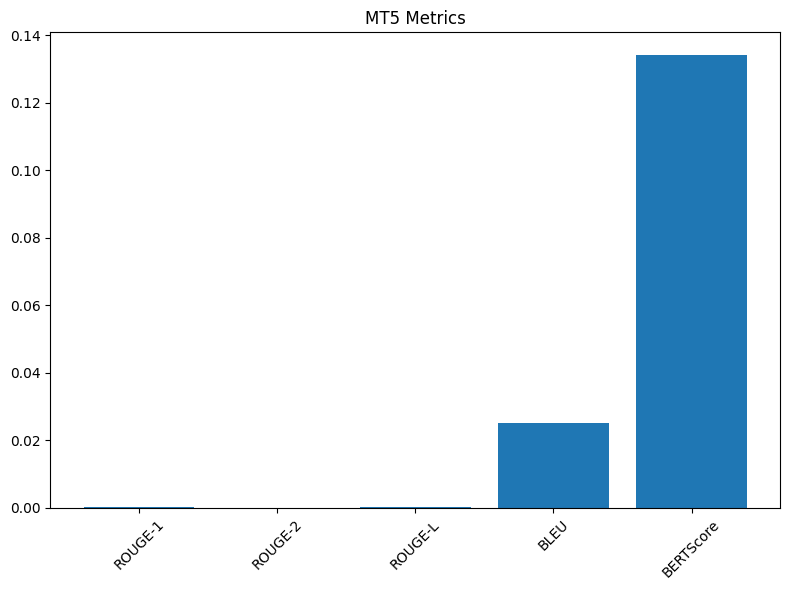

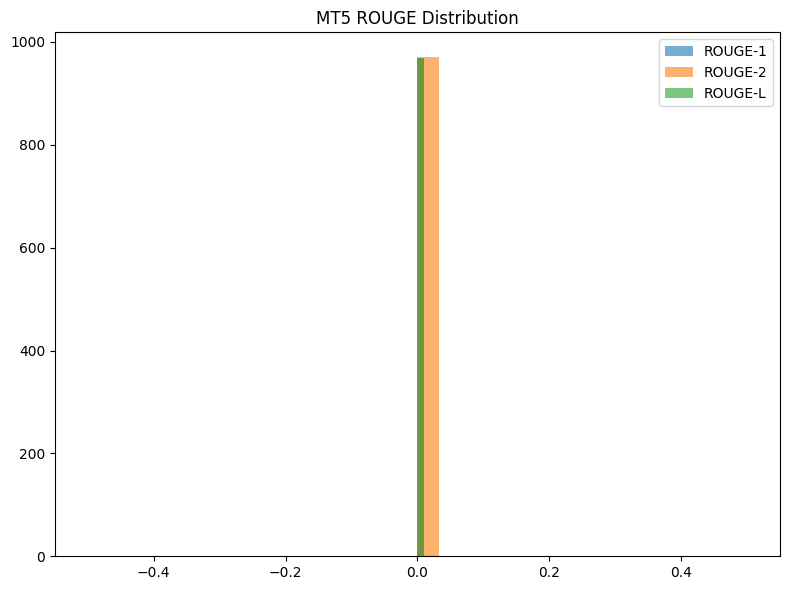


===== MT5 METRICS =====


,Metric,Score
0,ROUGE-1,0.000295
1,ROUGE-2,0.000000
2,ROUGE-L,0.000295
3,BLEU,0.025067
4,BERTScore,0.134116



===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
575,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,<extra_id_0>.
259,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,<extra_id_0>.
388,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,<extra_id_0>.
495,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,<extra_id_0>.
70,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,<extra_id_0>.



Saved to: /content/drive/MyDrive/ZEROSHOT_BENCHMARK/validation/mt5


In [ ]:
save_outputs("mt5", predictions, references, articles)

In [ ]:
clear_memory()

from transformers import MBart50TokenizerFast, MBartForConditionalGeneration

MODEL = "facebook/mbart-large-50-many-to-many-mmt"

tokenizer = MBart50TokenizerFast.from_pretrained(MODEL)

model = MBartForConditionalGeneration.from_pretrained(MODEL).to("cuda")

tokenizer.src_lang = "ml_IN"
tokenizer.tgt_lang = "ml_IN"

model.eval()

MBartForConditionalGeneration(
  (model): MBartModel(
    (shared): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
    (encoder): MBartEncoder(
      (embed_tokens): MBartScaledWordEmbedding(250054, 1024, padding_idx=1)
      (embed_positions): MBartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x MBartEncoderLayer(
          (self_attn): MBartSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): ReLU()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
    

In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    article = row["article"]
    reference = row["summary"]

    prompt = f"സംഗ്രഹം തയ്യാറാക്കുക: {article}"

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            forced_bos_token_id=tokenizer.lang_code_to_id["ml_IN"],
            max_new_tokens=80,
            num_beams=5,
            no_repeat_ngram_size=3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    pred = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

100%|██████████| 970/970 [09:00<00:00,  1.80it/s]


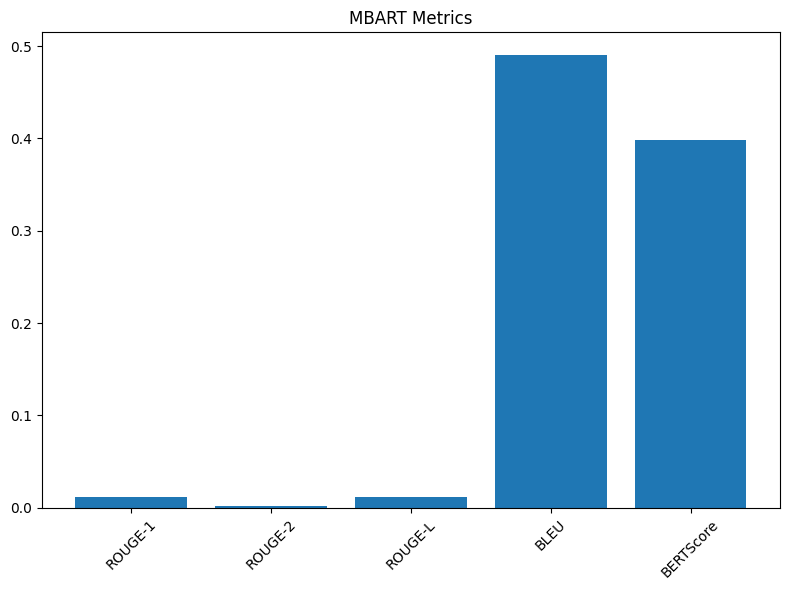

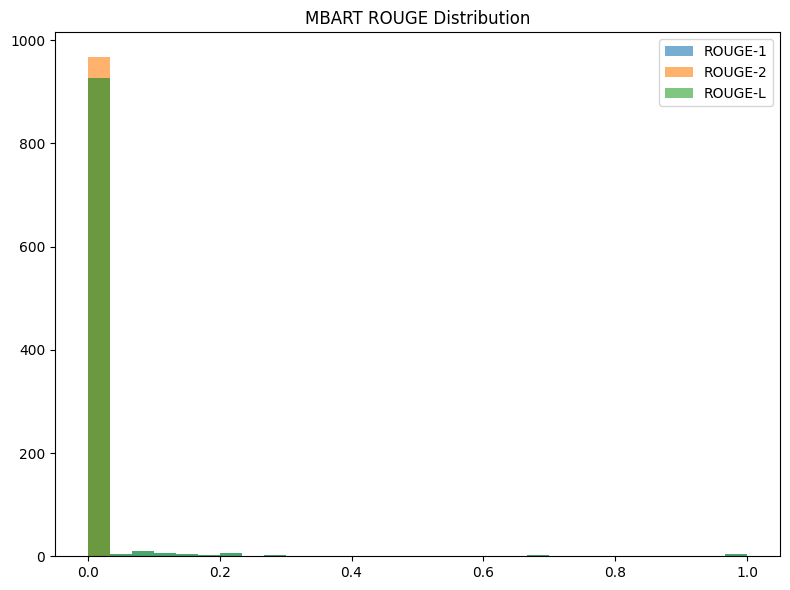


===== MBART METRICS =====


,Metric,Score
0,ROUGE-1,0.011512
1,ROUGE-2,0.001833
2,ROUGE-L,0.011512
3,BLEU,0.490460
4,BERTScore,0.397989



===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
575,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,Former General Secretary Prakash Karat declare...
259,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,♪ ♪
388,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,ആസാസിഫ് നെക്രോപോളിസില് നിന്നും മുപ്പതു മമ്മകളു...
495,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,The party's winter session begins.
70,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,♪ ♪



Saved to: /content/drive/MyDrive/ZEROSHOT_BENCHMARK/validation/mbart


In [ ]:
save_outputs("mbart", predictions, references, articles)


In [ ]:
clear_memory()

bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

MODEL = "bigscience/bloomz-1b7"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL,
    quantization_config=bnb,
    device_map="auto"
)

model.eval()

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

BloomForCausalLM(
  (transformer): BloomModel(
    (word_embeddings): Embedding(250880, 2048)
    (word_embeddings_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (h): ModuleList(
      (0-23): 24 x BloomBlock(
        (input_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (self_attention): BloomAttention(
          (query_key_value): Linear4bit(in_features=2048, out_features=6144, bias=True)
          (dense): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (attention_dropout): Dropout(p=0.0, inplace=False)
        )
        (post_attention_layernorm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
        (mlp): BloomMLP(
          (dense_h_to_4h): Linear4bit(in_features=2048, out_features=8192, bias=True)
          (gelu_impl): BloomGelu()
          (dense_4h_to_h): Linear4bit(in_features=8192, out_features=2048, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((2048,), eps=1e-05, elementwise_affi

In [ ]:
test_subset = df

In [ ]:
def format_prompt(article):
    return f"""
Instruction:
Summarize the following Malayalam news article in Malayalam only.
Do not translate.
Do not use English.
Generate only the summary.

Article:
{article}

Summary:
"""

In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(test_subset.iterrows(), total=len(test_subset)):

    article = row["article"]
    reference = row["summary"]

    prompt = format_prompt(article)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=384
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            num_beams=4,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    pred = generated.split("Summary:")[-1].strip()

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

  0%|          | 0/970 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
100%|██████████| 970/970 [40:18<00:00,  2.49s/it]


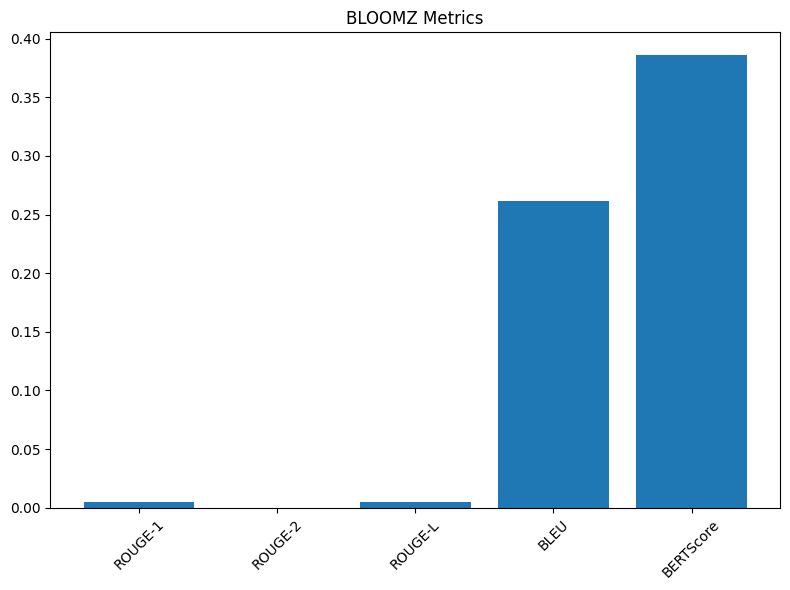

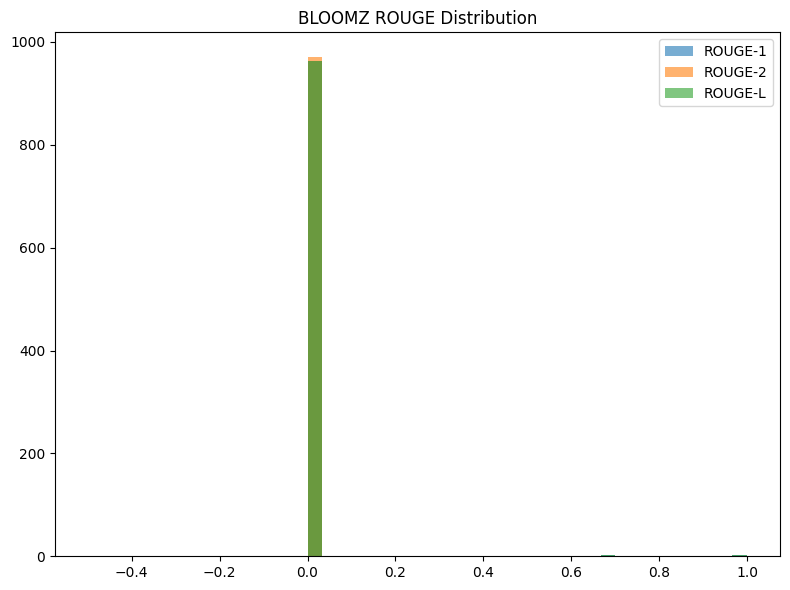


===== BLOOMZ METRICS =====


,Metric,Score
0,ROUGE-1,0.005086
1,ROUGE-2,0.000000
2,ROUGE-L,0.005086
3,BLEU,0.261870
4,BERTScore,0.386033



===== SAMPLE PREDICTIONS =====


,Article,Reference,Prediction
575,അഗര്ത്തല: ബിജെപിക്ക് ദേശീയ തലത്തില് ബദല് സിപിഎ...,ബിജെപിക്ക് ബദലാവാന് കമ്മ്യൂണിസ്റ്റുകാര്ക്കേ സാ...,ഡിവൈഎഫ്സി നേതാവ് ചന്ദ്രശേഖരനെ കൊലപ്പെടുത്തിയ ക...
259,നിയമവാഴ്ച നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാ...,നിയമത്തിനുമുന്നിൽ എല്ലാവരും സമന്മാരാണ്. ജനാധിപ...,കാലിഫോർണിയ സർവ്വകലാശാലയിലെ കോളേജ് വിദ്യാർത്ഥിയ...
388,നൈൽ നദിയുടെ പടിഞ്ഞാറൻ തീരത്തുള്ള പുരാതന പട്ടണമ...,തടിയില് തീര്ത്ത മുപ്പത് മമ്മികളുടെ ശവക്കല്ലറ ക...,കാലിഫോർണിയയിലെ ടെക്സസ് സർവ്വകലാശാലയിലെ ചരിത്രക...
495,ദില്ലി: പാര്ലമെന്റിന്റെ ശൈത്യകാല സെഷന് ആരംഭിക്...,ശിവസേന ഇനി ബിജെപിയുമായി കൊമ്പുകോര്ക്കും.... രാ...,ഡിസംബറിൽ പാരലമെന്റിൽ നടക്കുന്ന സെഷനിലേക്ക് എൻ‌...
70,കോ ത മം ഗ ലം: കോ ത മം ഗ ലം മാ ർ ത്തോ മ്മ ചെ റി...,യാക്കോബായ സഭയുടെ പാരമ്പര്യവും പള്ളികളും സംരക്ഷ...,റിപ്പോർട്ട്: തിങ്കളാഴ്ച ഉച്ചവരെയുള്ള കണക്ക് അന...



Saved to: /content/drive/MyDrive/ZEROSHOT_BENCHMARK/validation/bloomz


In [ ]:
save_outputs("bloomz", predictions, references, articles)

In [ ]:
import gc
import torch

del model
del tokenizer

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print(torch.cuda.memory_allocated()/1e9)

14.001767936
